In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_dataset.csv")
print(df.head())

print(df.tail())

print(df.shape)

print(df.columns)


  show_id            title     type  release_year        genre country  \
0   s0001  Netflix Title 1    Movie          2010  Documentary   India   
1   s0002  Netflix Title 2    Movie          2023        Drama     USA   
2   s0003  Netflix Title 3    Movie          2016  Documentary   Spain   
3   s0004  Netflix Title 4  TV Show          2010      Romance   Japan   
4   s0005  Netflix Title 5    Movie          2016      Romance   India   

   rating  duration_min  views_millions  
0     6.1            77           184.4  
1     5.4            89           126.8  
2     8.2           113            55.9  
3     5.7           114            85.7  
4     5.5           108            25.1  
   show_id              title     type  release_year        genre country  \
95   s0096   Netflix Title 96  TV Show          2010      Romance  Canada   
96   s0097   Netflix Title 97  TV Show          2024  Documentary      UK   
97   s0098   Netflix Title 98  TV Show          2025     Thriller  Canad

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   show_id         100 non-null    str    
 1   title           100 non-null    str    
 2   type            100 non-null    str    
 3   release_year    100 non-null    int64  
 4   genre           100 non-null    str    
 5   country         100 non-null    str    
 6   rating          100 non-null    float64
 7   duration_min    100 non-null    int64  
 8   views_millions  100 non-null    float64
dtypes: float64(2), int64(2), str(5)
memory usage: 7.2 KB
None


In [14]:
print(df.isnull().sum())

show_id           0
title             0
type              0
release_year      0
genre             0
country           0
rating            0
duration_min      0
views_millions    0
dtype: int64


In [15]:
print(df.describe())

       release_year      rating  duration_min  views_millions
count    100.000000  100.000000    100.000000      100.000000
mean    2017.250000    7.212000    118.120000      128.775000
std        4.515685    1.285842     33.573462       73.078645
min     2010.000000    5.000000     62.000000        2.400000
25%     2013.000000    6.075000     89.000000       68.550000
50%     2017.500000    7.100000    116.000000      129.150000
75%     2021.000000    8.325000    145.250000      189.825000
max     2025.000000    9.500000    180.000000      249.600000


In [16]:
print(df.duplicated().sum())

0


type
Movie      56
TV Show    44
Name: count, dtype: int64


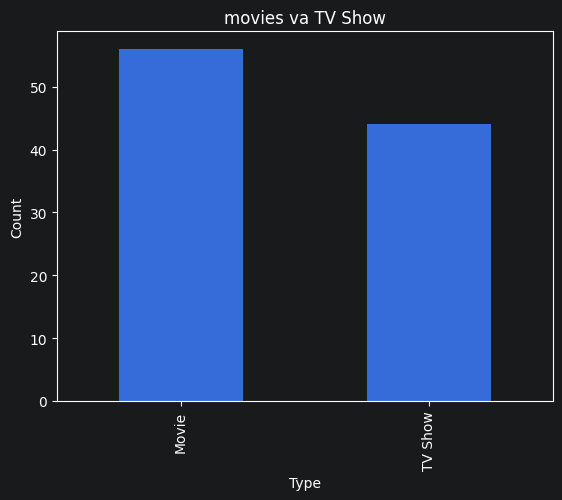

In [17]:
type_count = df['type'].value_counts()
print(type_count)
type_count.plot(kind='bar')
plt.title("movies va TV Show")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

genre
Documentary    17
Thriller       16
Drama          14
Romance        14
Comedy         14
Action         13
Sci-Fi         12
Name: count, dtype: int64


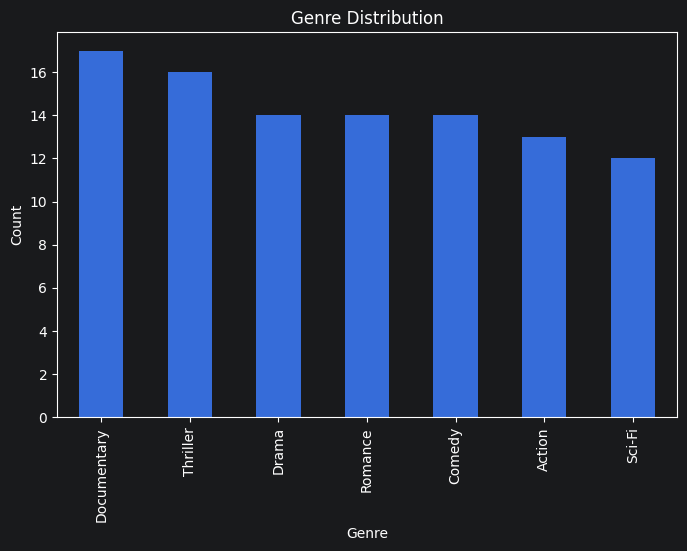

In [18]:
genre_count = df['genre'].value_counts()

print(genre_count)

genre_count.plot(kind='bar', figsize=(8,5))

plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

country
USA            21
UK             18
Japan          16
India          12
Canada         12
Spain          11
South Korea    10
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

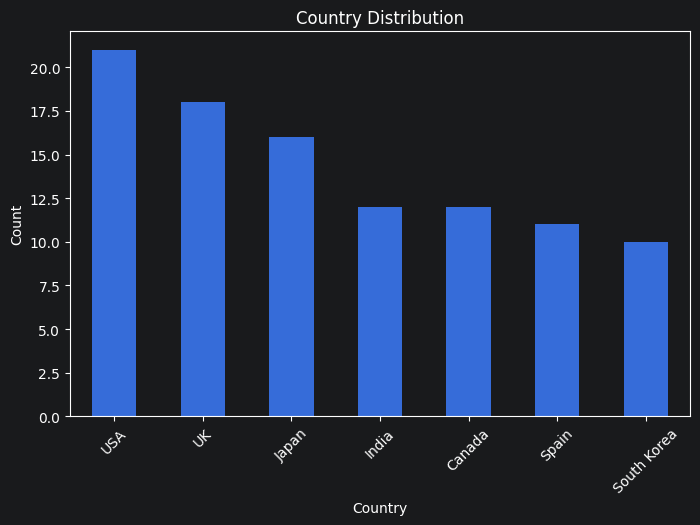

In [21]:
country_count = df['country'].value_counts()
print(country_count)
country_count.plot(kind='bar', figsize=(8,5))
plt.title("Country Distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.show

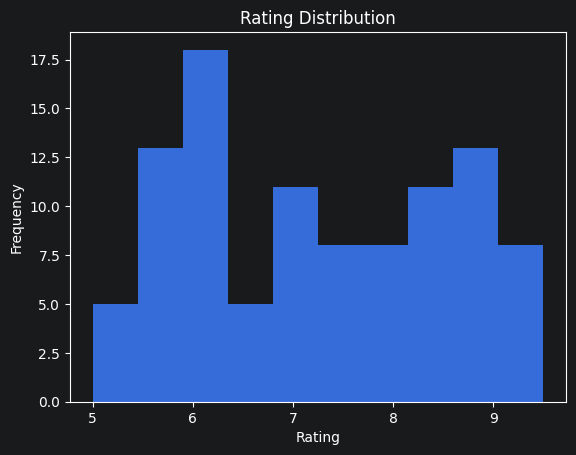

In [22]:
plt.hist(df['rating'], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

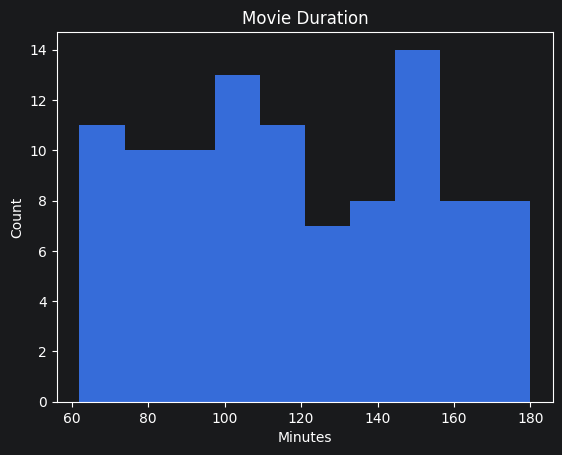

In [23]:
plt.hist(df['duration_min'], bins=10)

plt.title("Movie Duration")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

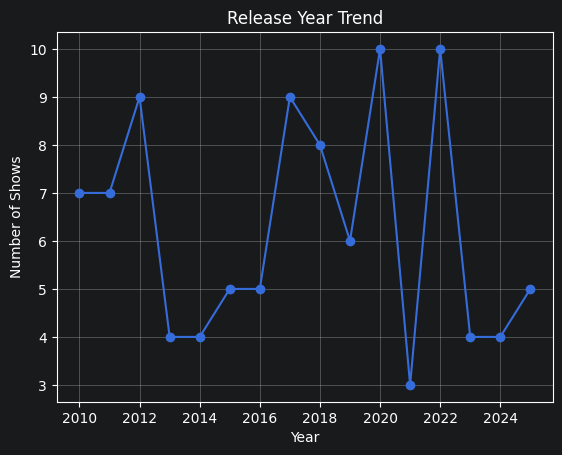

In [24]:
year = df['release_year'].value_counts().sort_index()

year.plot(kind='line', marker='o')

plt.title("Release Year Trend")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.grid(True)

plt.show()

               title  views_millions
44  Netflix Title 45           249.6
62  Netflix Title 63           246.1
60  Netflix Title 61           245.3
90  Netflix Title 91           241.0
89  Netflix Title 90           237.0
66  Netflix Title 67           235.2
42  Netflix Title 43           233.7
45  Netflix Title 46           233.4
56  Netflix Title 57           232.8
25  Netflix Title 26           232.3


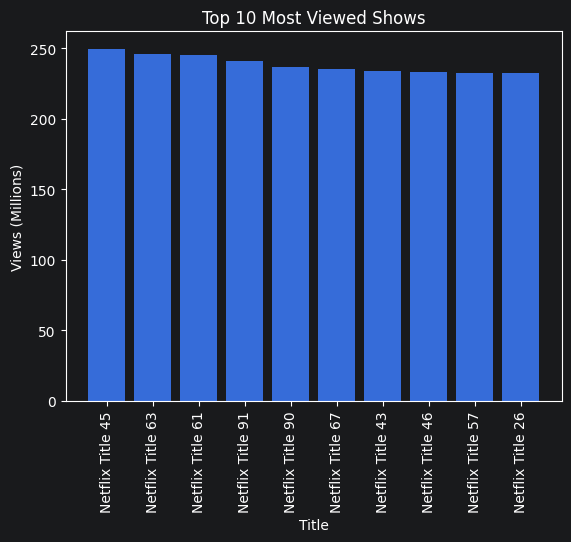

In [25]:
top = df.sort_values(by='views_millions', ascending=False).head(10)

print(top[['title','views_millions']])

plt.bar(top['title'], top['views_millions'])

plt.xticks(rotation=90)

plt.title("Top 10 Most Viewed Shows")

plt.xlabel("Title")

plt.ylabel("Views (Millions)")

plt.show()

In [26]:
top_rating = df.sort_values(by='rating', ascending=False).head(10)

print(top_rating[['title','rating']])

               title  rating
15  Netflix Title 16     9.5
64  Netflix Title 65     9.3
52  Netflix Title 53     9.3
37  Netflix Title 38     9.3
88  Netflix Title 89     9.3
81  Netflix Title 82     9.2
56  Netflix Title 57     9.2
58  Netflix Title 59     9.1
78  Netflix Title 79     9.0
23  Netflix Title 24     9.0


genre
Action         7.115385
Comedy         7.314286
Documentary    6.947059
Drama          7.250000
Romance        6.935714
Sci-Fi         7.250000
Thriller       7.662500
Name: rating, dtype: float64


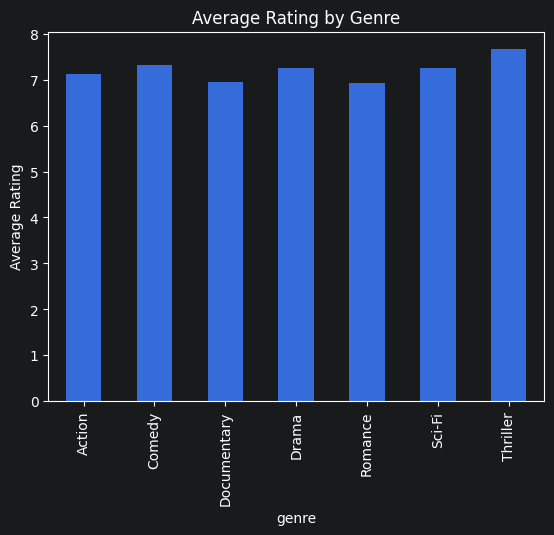

In [27]:
genre_rating = df.groupby('genre')['rating'].mean()

print(genre_rating)

genre_rating.plot(kind='bar')

plt.title("Average Rating by Genre")

plt.ylabel("Average Rating")

plt.show()

genre
Action         125.161538
Comedy         132.864286
Documentary    155.047059
Drama           85.985714
Romance        144.671429
Sci-Fi         153.116667
Thriller       105.493750
Name: views_millions, dtype: float64


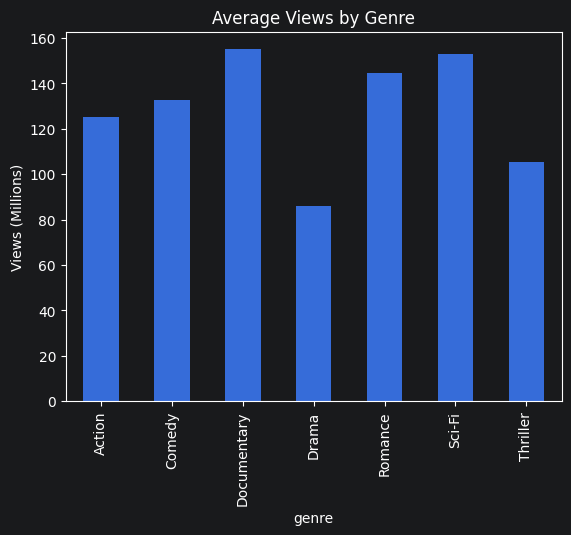

In [28]:
genre_views = df.groupby('genre')['views_millions'].mean()

print(genre_views)

genre_views.plot(kind='bar')

plt.title("Average Views by Genre")

plt.ylabel("Views (Millions)")

plt.show()

In [29]:
correlation = df[['rating','duration_min','views_millions']].corr()

print(correlation)

                  rating  duration_min  views_millions
rating          1.000000     -0.044209       -0.034348
duration_min   -0.044209      1.000000        0.093315
views_millions -0.034348      0.093315        1.000000


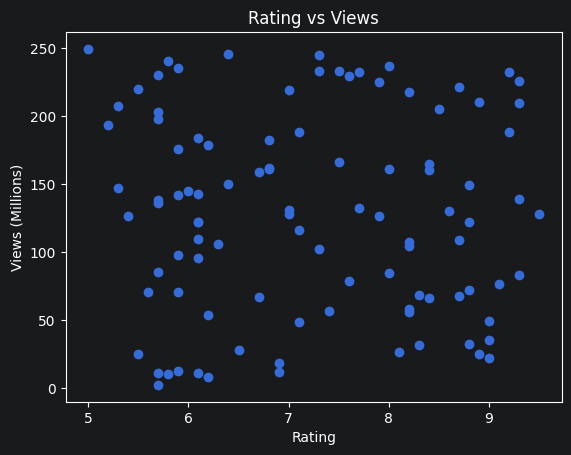

In [30]:
plt.scatter(df['rating'], df['views_millions'])

plt.xlabel("Rating")

plt.ylabel("Views (Millions)")

plt.title("Rating vs Views")

plt.show()

In [31]:
highest = df.loc[df['rating'].idxmax()]

print(highest)

show_id                      s0016
title             Netflix Title 16
type                       TV Show
release_year                  2022
genre                       Action
country                         UK
rating                         9.5
duration_min                    77
views_millions               127.9
Name: 15, dtype: object


In [32]:
longest = df.loc[df['duration_min'].idxmax()]

print(longest)

show_id                      s0013
title             Netflix Title 13
type                       TV Show
release_year                  2022
genre                       Action
country                        USA
rating                         5.9
duration_min                   180
views_millions               142.2
Name: 12, dtype: object


In [33]:
most_viewed = df.loc[df['views_millions'].idxmax()]

print(most_viewed)

show_id                      s0045
title             Netflix Title 45
type                       TV Show
release_year                  2020
genre                      Romance
country                        USA
rating                         5.0
duration_min                   139
views_millions               249.6
Name: 44, dtype: object


In [34]:
print("Average Rating :", df['rating'].mean())

print("Average Duration :", df['duration_min'].mean())

print("Average Views :", df['views_millions'].mean())

print("Most Common Genre :", df['genre'].mode()[0])

print("Most Common Country :", df['country'].mode()[0])

print("Most Common Type :", df['type'].mode()[0])

Average Rating : 7.212000000000001
Average Duration : 118.12
Average Views : 128.77499999999998
Most Common Genre : Documentary
Most Common Country : USA
Most Common Type : Movie
